In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
import joblib
import os
# Load data
df = pd.read_csv('../data/spy_features.csv', parse_dates=['Date'], index_col='Date')

df = df.sort_index()

print(df.shape)
print(df.columns.tolist())
print(df.head())

(2939, 25)
['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC', 'Label', 'Daily_Return']
                 Close        High         Low        Open     Volume  \
Date                                                                    
2014-10-16  153.016907  154.093042  150.240304  150.379953  270391000   
2014-10-17  154.824188  155.875681  154.125926  154.783112  214625000   
2014-10-20  156.327454  156.450670  154.495559  154.544846  130011000   
2014-10-21  159.424438  159.531222  157.296798  157.461092  154949000   
2014-10-22  158.290756  160.114440  158.225036  159.703701  151822000   

                  RSI      MACD  MACD_Signal  MACD_Hist    BB_Upper  ...  \
Date                                                                 ...   
2014-10-16  29.535651 -2.301859    -1.390111  -0.911747  166.981727  

In [2]:
# Drop redundant features
cols_to_drop = ['High', 'Low', 'Open', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_200', 'EMA_12', 'EMA_26']

df = df.drop(columns=cols_to_drop)

df = df.dropna()

# Define X and y
X = df.drop(columns=['Label'])
y = df['Label']


print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {X.columns.tolist()}")
print(f"Label distribution:\n{y.value_counts()}")

X shape: (2938, 15)
y shape: (2938,)
Features: ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'SMA_50', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC', 'Daily_Return']
Label distribution:
Label
1    1614
0    1324
Name: count, dtype: int64


In [3]:
# walk-forward splitter
tscv = TimeSeriesSplit(n_splits=5)

# scaler, will be fitted inside each fold
scaler = StandardScaler()

# preview the fold sizes
print("Walk-forward fold sizes:")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    print(f"Fold {fold}: Train={len(train_idx)} rows, Validate={len(val_idx)} rows")

Walk-forward fold sizes:
Fold 1: Train=493 rows, Validate=489 rows
Fold 2: Train=982 rows, Validate=489 rows
Fold 3: Train=1471 rows, Validate=489 rows
Fold 4: Train=1960 rows, Validate=489 rows
Fold 5: Train=2449 rows, Validate=489 rows


In [4]:
for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
    print(f"Fold {i+1}: train {X.index[train_idx[0]]} to {X.index[train_idx[-1]]}, "
          f"val {X.index[val_idx[0]]} to {X.index[val_idx[-1]]}")

Fold 1: train 2014-10-17 00:00:00 to 2016-09-30 00:00:00, val 2016-10-03 00:00:00 to 2018-09-11 00:00:00
Fold 2: train 2014-10-17 00:00:00 to 2018-09-11 00:00:00, val 2018-09-12 00:00:00 to 2020-08-20 00:00:00
Fold 3: train 2014-10-17 00:00:00 to 2020-08-20 00:00:00, val 2020-08-21 00:00:00 to 2022-08-01 00:00:00
Fold 4: train 2014-10-17 00:00:00 to 2022-08-01 00:00:00, val 2022-08-02 00:00:00 to 2024-07-12 00:00:00
Fold 5: train 2014-10-17 00:00:00 to 2024-07-12 00:00:00, val 2024-07-15 00:00:00 to 2026-06-25 00:00:00


In [5]:
# Store metrics
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    # Split into train and validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train Logistic Regression
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Predict on validation data
    y_pred = model.predict(X_val_scaled)

    # Calculate metrics
    metrics = {
        'fold': fold,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }
    fold_metrics.append(metrics)
    print(f"Fold {fold}: Accuracy={metrics['accuracy']:.3f}, Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}, F1={metrics['f1']:.3f}")

# Average
print("\n--- Logistic Regression Average ---")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    avg = np.mean([f[metric] for f in fold_metrics])
    print(f"Average {metric}: {avg:.3f}")

Fold 1: Accuracy=0.429, Precision=0.417, Recall=0.018, F1=0.035
Fold 2: Accuracy=0.509, Precision=0.555, Recall=0.703, F1=0.620
Fold 3: Accuracy=0.538, Precision=0.538, Recall=1.000, F1=0.699
Fold 4: Accuracy=0.540, Precision=0.539, Recall=0.981, F1=0.696
Fold 5: Accuracy=0.550, Precision=0.560, Recall=0.949, F1=0.704

--- Logistic Regression Average ---
Average accuracy: 0.513
Average precision: 0.522
Average recall: 0.730
Average f1: 0.551


Average accuracy is below 55% baseline

In [6]:
# Store metrics for each fold
rf_fold_metrics = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    # Split into train and validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train_scaled, y_train)
    # Predict on validation data
    y_pred = rf_model.predict(X_val_scaled)

    # Calculate metrics
    rf_metrics = {
        'fold': fold,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }
    rf_fold_metrics.append(rf_metrics)
    print(f"Fold {fold}: Accuracy={rf_metrics['accuracy']:.3f}, Precision={rf_metrics['precision']:.3f}, Recall={rf_metrics['recall']:.3f}, F1={rf_metrics['f1']:.3f}")

    # Average across all folds
print("\n--- Random Forest Average ---")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    avg = np.mean([f[metric] for f in rf_fold_metrics])
    print(f"Average {metric}: {avg:.3f}")

Fold 1: Accuracy=0.474, Precision=0.643, Recall=0.162, F1=0.259
Fold 2: Accuracy=0.474, Precision=0.551, Recall=0.423, F1=0.479
Fold 3: Accuracy=0.474, Precision=0.625, Recall=0.057, F1=0.105
Fold 4: Accuracy=0.497, Precision=0.530, Recall=0.546, F1=0.538
Fold 5: Accuracy=0.542, Precision=0.570, Recall=0.772, F1=0.655

--- Random Forest Average ---
Average accuracy: 0.492
Average precision: 0.584
Average recall: 0.392
Average f1: 0.407


Precision is above baseline
100 trees may be too little

In [7]:
# Store metrics
gb_fold_metrics = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train Gradient Boosting
    gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    gb_model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = gb_model.predict(X_val_scaled)

    #calculate metrics
    gb_metrics = {
        'fold': fold,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }
    gb_fold_metrics.append(gb_metrics)
    print(f"Fold {fold}: Accuracy={gb_metrics['accuracy']:.3f}, Precision={gb_metrics['precision']:.3f}, Recall={gb_metrics['recall']:.3f}, F1={gb_metrics['f1']:.3f}")

    # Average
print("\n--- Gradient Boosting Average ---")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    avg = np.mean([f[metric] for f in gb_fold_metrics])
    print(f"Average {metric}: {avg:.3f}")

Fold 1: Accuracy=0.456, Precision=0.628, Recall=0.097, F1=0.169
Fold 2: Accuracy=0.474, Precision=0.559, Recall=0.373, F1=0.447
Fold 3: Accuracy=0.462, Precision=0.000, Recall=0.000, F1=0.000
Fold 4: Accuracy=0.481, Precision=0.513, Recall=0.588, F1=0.548
Fold 5: Accuracy=0.546, Precision=0.588, Recall=0.656, F1=0.620

--- Gradient Boosting Average ---
Average accuracy: 0.484
Average precision: 0.458
Average recall: 0.343
Average f1: 0.357


Did not perform well, fold 3 contains data from COVID likely impacting prediction due to volatility

In [8]:
hgb_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Train Hist Gradient Boosting
    hgb_model = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
    hgb_model.fit(X_train_scaled, y_train)

    y_pred = hgb_model.predict(X_val_scaled)

    hgb_metrics = {
        'fold': fold,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'f1': f1_score(y_val, y_pred)
    }
    hgb_fold_metrics.append(hgb_metrics)
    print(f"Fold {fold}: Accuracy={hgb_metrics['accuracy']:.3f}, Precision={hgb_metrics['precision']:.3f}, Recall={hgb_metrics['recall']:.3f}, F1={hgb_metrics['f1']:.3f}")

print("\n--- Hist Gradient Boosting Average ---")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    avg = np.mean([f[metric] for f in hgb_fold_metrics])
    print(f"Average {metric}: {avg:.3f}")

Fold 1: Accuracy=0.476, Precision=0.624, Recall=0.191, F1=0.293
Fold 2: Accuracy=0.468, Precision=0.542, Recall=0.437, F1=0.484
Fold 3: Accuracy=0.501, Precision=0.554, Recall=0.373, F1=0.445
Fold 4: Accuracy=0.505, Precision=0.532, Recall=0.641, F1=0.581
Fold 5: Accuracy=0.550, Precision=0.567, Recall=0.855, F1=0.682

--- Hist Gradient Boosting Average ---
Average accuracy: 0.500
Average precision: 0.564
Average recall: 0.500
Average f1: 0.497


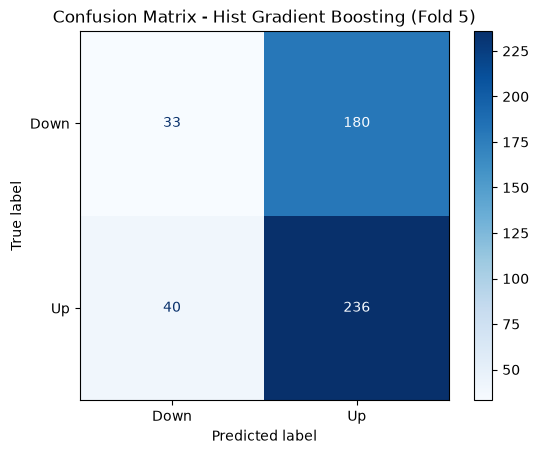

Confusion matrix saved to results/confusion_matrix.png


In [9]:
#confusion matrix
splits = list(tscv.split(X))
train_idx, val_idx = splits[4]  # index 4 = fold 5

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Retrain best model on fold 5
best_model = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=42)
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_val_scaled)

#Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Hist Gradient Boosting (Fold 5)')
plt.savefig('../results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to results/confusion_matrix.png")

In [10]:


# Full dataset scaler
scaler_v1 = StandardScaler()
X_scaled_v1 = scaler_v1.fit_transform(X)

#Train the final Hist Gradient Boosting model on everything
hgb_v1 = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    random_state=42
)
hgb_v1.fit(X_scaled_v1, y)

# then save both objects
os.makedirs('../models', exist_ok=True)

joblib.dump(hgb_v1, '../models/hgb_v1.joblib')
joblib.dump(scaler_v1, '../models/scaler_v1.joblib')

print("Saved model to ../models/hgb_v1.joblib")
print("Saved scaler to ../models/scaler_v1.joblib")

Saved model to ../models/hgb_v1.joblib
Saved scaler to ../models/scaler_v1.joblib


In [11]:
#collect out-of-sample results across all folds
oos_dates = []
oos_predictions = []
oos_actuals = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    hgb_model = HistGradientBoostingClassifier(
        max_iter=100, learning_rate=0.1, random_state=42
    )
    hgb_model.fit(X_train_scaled, y_train)

    y_pred = hgb_model.predict(X_val_scaled)

    # Collect dates, predictions, and actual outcomes
    oos_dates.append(X_val.index)
    oos_predictions.append(y_pred)
    oos_actuals.append(y_val.values)

    print(f"Fold {fold} collected: {len(X_val)} rows")

# Combine folds into one continuous DataFrame
oos_results_df = pd.DataFrame({
    'date': [d for dates in oos_dates for d in dates],
    'predicted': [p for preds in oos_predictions for p in preds],
    'actual': [a for actuals in oos_actuals for a in actuals]
})

# Sort by date as a safety check
oos_results_df = oos_results_df.sort_values('date').reset_index(drop=True)

print(f"\nTotal out-of-sample rows: {len(oos_results_df)}")
oos_results_df.head()

Fold 1 collected: 489 rows
Fold 2 collected: 489 rows
Fold 3 collected: 489 rows
Fold 4 collected: 489 rows
Fold 5 collected: 489 rows

Total out-of-sample rows: 2445


,date,predicted,actual
0,2016-10-03,1,0
1,2016-10-04,1,1
2,2016-10-05,1,1
3,2016-10-06,1,0
4,2016-10-07,1,1


In [12]:
daily_returns = df['Daily_Return']

# Merge into oos_results_df by matching on date
oos_results_df = oos_results_df.merge(
    daily_returns.rename('daily_return'),
    left_on='date',
    right_index=True,
    how='left'
)

oos_results_df.head()

,date,predicted,actual,daily_return
0,2016-10-03,1,0,-0.002404
1,2016-10-04,1,1,-0.005098
2,2016-10-05,1,1,0.004425
3,2016-10-06,1,0,0.000696
4,2016-10-07,1,1,-0.003429


In [13]:
# Create a "next day return" column in df: shift Daily_Return backward by 1 row so that today's row holds tomorrow's return (matches how the label was built)
df['Next_Day_Return'] = df['Daily_Return'].shift(-1)

# Redo merge using Next_Day_Return instead of Daily_Return
oos_results_df = oos_results_df.drop(columns=['daily_return'])  # remove the misaligned column

oos_results_df = oos_results_df.merge(
    df['Next_Day_Return'].rename('daily_return'),
    left_on='date',
    right_index=True,
    how='left'
)

oos_results_df.head()

,date,predicted,actual,daily_return
0,2016-10-03,1,0,-0.005098
1,2016-10-04,1,1,0.004425
2,2016-10-05,1,1,0.000696
3,2016-10-06,1,0,-0.003429
4,2016-10-07,1,1,0.005208


In [14]:
mismatch = oos_results_df[(oos_results_df['actual'] == 1) & (oos_results_df['daily_return'] < 0)]
mismatch_count = len(mismatch)
print(f"Rows where actual=1 but daily_return is negative: {mismatch_count}")

mismatch2 = oos_results_df[(oos_results_df['actual'] == 0) & (oos_results_df['daily_return'] > 0)]
mismatch2_count = len(mismatch2)
print(f"Rows where actual=0 but daily_return is positive: {mismatch2_count}")

Rows where actual=1 but daily_return is negative: 0
Rows where actual=0 but daily_return is positive: 0


In [15]:
# Strategy return: earn the real return if model predicted "up" (1), otherwise earn 0% (sitting in cash)
oos_results_df['strategy_return'] = oos_results_df.apply(
    lambda row: row['daily_return'] if row['predicted'] == 1 else 0,
    axis=1
)

oos_results_df.head()

,date,predicted,actual,daily_return,strategy_return
0,2016-10-03,1,0,-0.005098,-0.005098
1,2016-10-04,1,1,0.004425,0.004425
2,2016-10-05,1,1,0.000696,0.000696
3,2016-10-06,1,0,-0.003429,-0.003429
4,2016-10-07,1,1,0.005208,0.005208


In [16]:
# Cumulative return for the strategy (long/cash based on model predictions)
oos_results_df['strategy_cumulative'] = (1 + oos_results_df['strategy_return']).cumprod()

# Cumulative return for buy-and-hold (just holding SPY the whole time)
oos_results_df['buyhold_cumulative'] = (1 + oos_results_df['daily_return']).cumprod()

# Convert both to percentage gain/loss since day 1
oos_results_df['strategy_pct'] = (oos_results_df['strategy_cumulative'] - 1) * 100
oos_results_df['buyhold_pct'] = (oos_results_df['buyhold_cumulative'] - 1) * 100

oos_results_df[['date', 'strategy_pct', 'buyhold_pct']].tail()

,date,strategy_pct,buyhold_pct
2440,2026-06-18,106.718631,302.955104
2441,2026-06-22,103.716673,297.103409
2442,2026-06-23,103.622247,296.919345
2443,2026-06-24,103.622247,297.493145
2444,2026-06-25,NaN,NaN


In [17]:
###oos_results_df['daily_return'].isna().sum()

oos_results_df = oos_results_df.dropna(subset=['daily_return']).reset_index(drop=True)

print(f"Rows after dropping NaN: {len(oos_results_df)}")
oos_results_df[['date', 'strategy_pct', 'buyhold_pct']].tail()

Rows after dropping NaN: 2444


,date,strategy_pct,buyhold_pct
2439,2026-06-17,107.371224,304.227199
2440,2026-06-18,106.718631,302.955104
2441,2026-06-22,103.716673,297.103409
2442,2026-06-23,103.622247,296.919345
2443,2026-06-24,103.622247,297.493145


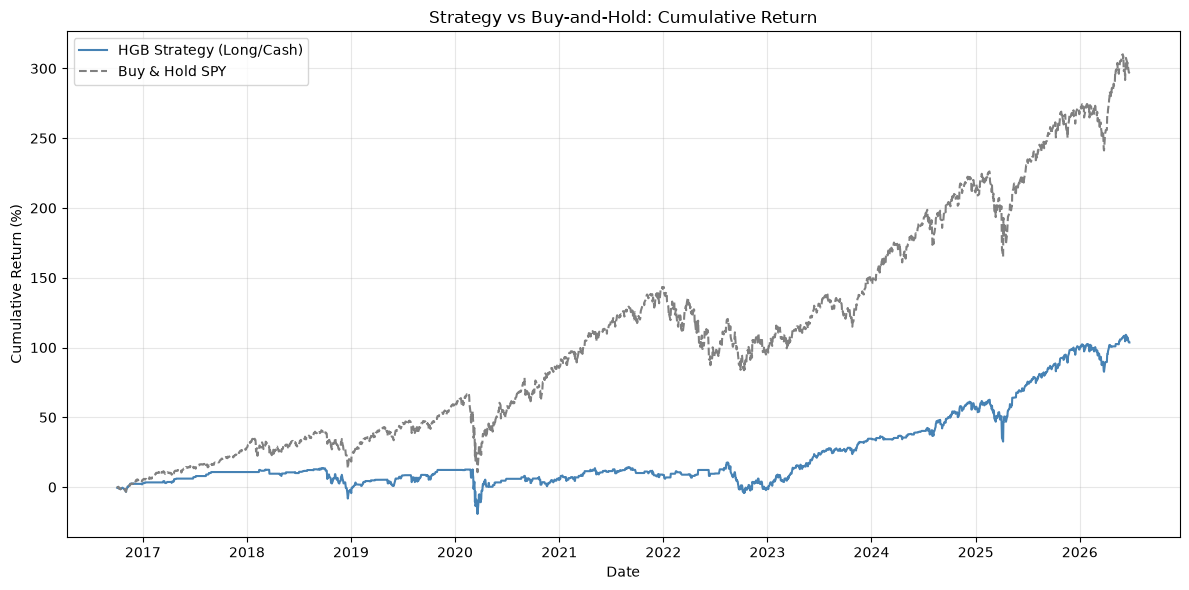

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(oos_results_df['date'], oos_results_df['strategy_pct'], label='HGB Strategy (Long/Cash)', color='steelblue')
plt.plot(oos_results_df['date'], oos_results_df['buyhold_pct'], label='Buy & Hold SPY', color='gray', linestyle='--')

plt.title('Strategy vs Buy-and-Hold: Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('../results/equity_curve.png', dpi=150)
plt.show()

Long/cash strategy returned ~104% over the out-of-sample period vs ~297% for buy-and-hold. The model's "up" bias causes it to sit out too often, missing much of the market's long-term growth.

In [19]:
import numpy as np

def calculate_sharpe(returns, periods_per_year=252):
    """Annualized Sharpe ratio, assuming 0% risk-free rate."""
    mean_return = returns.mean()
    std_return = returns.std()
    sharpe = (mean_return / std_return) * np.sqrt(periods_per_year)
    return sharpe

def calculate_max_drawdown(cumulative_returns):
    """Max drawdown as a percentage, from a cumulative return multiplier series."""
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_dd = drawdown.min() * 100  # as a percentage, will be negative
    return max_dd

# Strategy metrics
strategy_sharpe = calculate_sharpe(oos_results_df['strategy_return'])
strategy_max_dd = calculate_max_drawdown(oos_results_df['strategy_cumulative'])

# Buy-and-hold metrics
buyhold_sharpe = calculate_sharpe(oos_results_df['daily_return'])
buyhold_max_dd = calculate_max_drawdown(oos_results_df['buyhold_cumulative'])

print(f"Strategy   -> Sharpe: {strategy_sharpe:.3f}, Max Drawdown: {strategy_max_dd:.2f}%")
print(f"Buy & Hold -> Sharpe: {buyhold_sharpe:.3f}, Max Drawdown: {buyhold_max_dd:.2f}%")

Strategy   -> Sharpe: 0.564, Max Drawdown: -28.95%
Buy & Hold -> Sharpe: 0.877, Max Drawdown: -33.72%


Buy-and-hold wins on both risk-adjusted return and drawdown, despite the strategy's more conservative positioning.

In [20]:
model_comparison = {
    "logistic_regression": {
        "accuracy": 0.513,
        "precision": 0.522,
        "recall": 0.730,
        "f1": 0.551
    },
    "random_forest": {
        "accuracy": 0.492,
        "precision": 0.584,
        "recall": 0.392,
        "f1": 0.407
    },
    "gradient_boosting": {
        "accuracy": 0.484,
        "precision": 0.458,
        "recall": 0.343,
        "f1": 0.357
    },
    "hist_gradient_boosting": {
        "accuracy": 0.500,
        "precision": 0.564,
        "recall": 0.500,
        "f1": 0.497
    }
}

In [21]:
baseline = {
    "strategy": "always predict up",
    "accuracy": 0.550
}

equity_curve_metrics = {
    "strategy": {
        "sharpe_ratio": round(strategy_sharpe, 3),
        "max_drawdown_pct": round(strategy_max_dd, 2),
        "total_return_pct": round(oos_results_df['strategy_pct'].iloc[-1], 2)
    },
    "buy_and_hold": {
        "sharpe_ratio": round(buyhold_sharpe, 3),
        "max_drawdown_pct": round(buyhold_max_dd, 2),
        "total_return_pct": round(oos_results_df['buyhold_pct'].iloc[-1], 2)
    }
}

In [22]:
from datetime import date

metadata = {
    "training_date": str(date.today()),
    "model_type": "HistGradientBoostingClassifier",
    "hyperparameters": {
        "max_iter": 100,
        "learning_rate": 0.1,
        "random_state": 42
    },
    "features": list(X.columns)
}

In [23]:
import json
import os

metrics_output = {
    "model_comparison": model_comparison,
    "baseline": baseline,
    "selected_model": "hist_gradient_boosting",
    "equity_curve_metrics": equity_curve_metrics,
    "metadata": metadata
}

os.makedirs('../results', exist_ok=True)

with open('../results/metrics.json', 'w') as f:
    json.dump(metrics_output, f, indent=4)

print("Saved to ../results/metrics.json")

Saved to ../results/metrics.json
